In [ ]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph

c:\Users\ka448\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
class AgentState(TypedDict):
    values: List[int]
    name: str
    result: str
    

In [3]:
def process_values(state: AgentState) -> AgentState:
    """The Agent processes the values and updates the result."""
    state["result"] = state["name"] + " Your sum is: "+ str({sum(state["values"])})
    return state


In [4]:
graph = StateGraph(AgentState)
graph.add_node("node", process_values)
graph.set_entry_point("node")
graph.set_finish_point("node")


In [5]:
graph

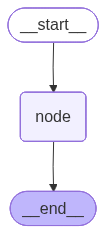

In [12]:
graph.compile()

In [6]:
test = graph.compile()

In [7]:
result = test.invoke({"values": [1, 2, 3], "name": "Alice", "result": ""})

In [8]:
result["result"]

'Alice Your sum is: {6}'

In [9]:
def addition(state: AgentState) -> AgentState:
    """The Agent processes the values and updates the result."""
    state["result"] = state["name"] + " Your sum is: "+ str({sum(state["values"])})
    return state

In [10]:
graph.add_node("addition_node", addition)

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [11]:
graph

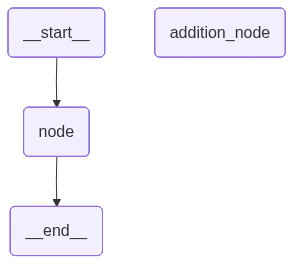

In [12]:
graph.compile()

In [13]:
graph.set_entry_point("addition_node")

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


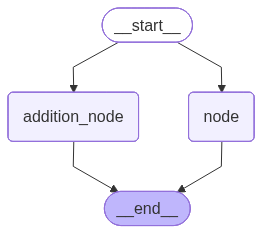

In [14]:
graph.compile()

In [15]:
two_node_test = graph.compile()

In [ ]:
test = two_node_test.invoke({"values": [1, 2, 3], "name": "Alice", "result": ""})

InvalidUpdateError: At key 'values': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE

: 